In [ ]:
# VisionX AI - Computer Vision Engine
# Install required libraries

!pip -q install ultralytics opencv-python-headless

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Load pretrained YOLO model
model = YOLO("yolo11n.pt")

print("VisionX AI model loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 1.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
VisionX AI model loaded successfully!


Saving me skunnutiwari.jpeg to me skunnutiwari.jpeg

image 1/1 /content/me skunnutiwari.jpeg: 640x544 2 persons, 572.9ms
Speed: 27.4ms preprocess, 572.9ms inference, 54.1ms postprocess per image at shape (1, 3, 640, 544)


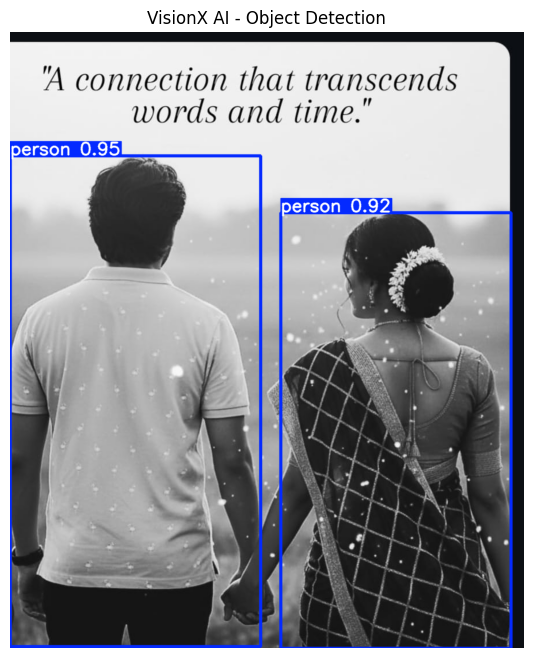

In [ ]:
# Upload an image
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Run object detection
results = model(image_path)

# Display result
result_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("VisionX AI - Object Detection")
plt.show()

In [ ]:
# Extract detected objects

result = results[0]

detections = []

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    detections.append({
        "object": model.names[class_id],
        "confidence": round(confidence, 3)
    })

print("Detected Objects:")
for item in detections:
    print(item)

Detected Objects:
{'object': 'person', 'confidence': 0.946}
{'object': 'person', 'confidence': 0.922}


In [ ]:
# VisionX AI - Classification Module

!pip -q install transformers torch torchvision

from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt

# Load image
image = Image.open(image_path).convert("RGB")

# AI image classification model
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Analyze image
classification_results = classifier(image)

print("VisionX AI - Image Classification\n")

for result in classification_results[:5]:
    print(
        f"{result['label']}: "
        f"{result['score'] * 100:.2f}%"
    )

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

VisionX AI - Image Classification

sunglass: 23.47%
book jacket, dust cover, dust jacket, dust wrapper: 16.79%
sunglasses, dark glasses, shades: 15.11%
bow tie, bow-tie, bowtie: 3.50%
neck brace: 2.76%


In [ ]:
# VisionX AI - Combined Analysis

print("=" * 50)
print("VISIONX AI ANALYSIS")
print("=" * 50)

print("\nDetected Objects:")
for item in detections:
    print(
        f"• {item['object']} "
        f"({item['confidence'] * 100:.1f}%)"
    )

print("\nImage Classification:")
for result in classification_results[:5]:
    print(
        f"• {result['label']} "
        f"({result['score'] * 100:.1f}%)"
    )

print("\nAnalysis completed successfully.")

VISIONX AI ANALYSIS

Detected Objects:
• person (94.6%)
• person (92.2%)

Image Classification:
• sunglass (23.5%)
• book jacket, dust cover, dust jacket, dust wrapper (16.8%)
• sunglasses, dark glasses, shades (15.1%)
• bow tie, bow-tie, bowtie (3.5%)
• neck brace (2.8%)

Analysis completed successfully.


In [ ]:
!pip -q install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
import easyocr

# English + Russian OCR
reader = easyocr.Reader(
    ['en', 'ru'],
    gpu=True
)

print("VisionX OCR module loaded!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% CompleteVisionX OCR module loaded!


In [ ]:
reader = easyocr.Reader(
    ['en', 'ru'],
    gpu=False
)

In [ ]:
# Run OCR
ocr_results = reader.readtext(image_path)

print("=" * 50)
print("VISIONX OCR RESULTS")
print("=" * 50)

if not ocr_results:
    print("No text detected.")

else:
    for bbox, text, confidence in ocr_results:
        print(
            f"Text: {text} | "
            f"Confidence: {confidence * 100:.2f}%"
        )

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


VISIONX OCR RESULTS
Text: "A connection that tronscends | Confidence: 57.26%
Text: words ond time | Confidence: 94.60%


In [ ]:
def extract_text(image_path):
    results = reader.readtext(image_path)

    extracted_text = []

    for bbox, text, confidence in results:
        if confidence >= 0.40:
            extracted_text.append(text)

    return "\n".join(extracted_text)


text = extract_text(image_path)

print("Extracted Text:")
print(text)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracted Text:
"A connection that tronscends
words ond time


In [ ]:
!pip -q install -U transformers sentencepiece accelerate

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_brain = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("VisionX AI Brain loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

VisionX AI Brain loaded successfully!


In [ ]:
prompt = """
You are VisionX AI.
Explain this image analysis:
Detected objects: person, laptop, mobile phone.
Detected text: Machine Learning Engineer.

Give a short professional analysis.
"""

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True
)

outputs = model_brain.generate(
    **inputs,
    max_new_tokens=150
)

answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(answer)

You are VisionX AI.


In [ ]:
prompt = """
Answer the following question briefly and clearly.

Question:
What objects are present in an image if the detected objects are person, laptop and mobile phone?

Answer:
"""

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    max_length=512,
    truncation=True
)

outputs = model_brain.generate(
    **inputs,
    max_new_tokens=100,
    num_beams=4,
    do_sample=False
)

answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print("VisionX AI:")
print(answer)

VisionX AI:
person, laptop and mobile phone


In [ ]:
def visionx_brain(detections, extracted_text):

    objects = ", ".join(
        [x["object"] for x in detections]
    )

    prompt = f"""
Analyze the following computer vision results.

Detected objects: {objects}

Detected text: {extracted_text}

Give a short report with:
Objects:
Text:
Summary:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    )

    outputs = model_brain.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        do_sample=False
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )


report = visionx_brain(
    detections,
    text
)

print("=" * 50)
print("VISIONX AI REPORT")
print("=" * 50)
print(report)

VISIONX AI REPORT
A connection that tronscends words ond time


In [ ]:
def create_visionx_report(detections, extracted_text):

    # Unique objects
    objects = []

    for item in detections:
        if item["object"] not in objects:
            objects.append(item["object"])

    # Object summary
    if objects:
        object_summary = ", ".join(objects)
    else:
        object_summary = "No objects detected"

    # Text summary
    if extracted_text.strip():
        text_summary = extracted_text.strip()
    else:
        text_summary = "No text detected"

    # Professional report
    report = f"""
VISIONX AI REPORT
=================

Detected Objects:
{object_summary}

Number of Objects:
{len(detections)}

Detected Text:
{text_summary}

System Status:
Analysis completed successfully.

Technology:
YOLO Object Detection + EasyOCR
"""

    return report


report = create_visionx_report(
    detections,
    text
)

print(report)


VISIONX AI REPORT

Detected Objects:
person

Number of Objects:
2

Detected Text:
"A connection that tronscends
words ond time

System Status:
Analysis completed successfully.

Technology:
YOLO Object Detection + EasyOCR



In [ ]:
print("OBJECTS")
print(detections)

print("\nOCR TEXT")
print(text)

print("\nAI REPORT")
print(report)

OBJECTS
[{'object': 'person', 'confidence': 0.946}, {'object': 'person', 'confidence': 0.922}]

OCR TEXT
"A connection that tronscends
words ond time

AI REPORT

VISIONX AI REPORT

Detected Objects:
person

Number of Objects:
2

Detected Text:
"A connection that tronscends
words ond time

System Status:
Analysis completed successfully.

Technology:
YOLO Object Detection + EasyOCR



In [ ]:
!pip -q install fastapi uvicorn nest-asyncio

In [6]:
from fastapi import FastAPI, UploadFile, File
import nest_asyncio
import uvicorn
import os

app = FastAPI(
    title="VisionX AI API",
    description="AI Computer Vision Analysis API",
    version="1.0"
)

@app.get("/")
def home():
    return {
        "project": "VisionX AI",
        "status": "online",
        "version": "1.0"
    }


@app.post("/analyze")
async def analyze_image(file: UploadFile = File(...)):

    # Save uploaded image
    file_path = "uploaded_image.jpg"

    with open(file_path, "wb") as f:
        f.write(await file.read())

    # YOLO detection
    results = model(file_path)

    detections = []

    for box in results[0].boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        detections.append({
            "object": model.names[class_id],
            "confidence": round(confidence, 3)
        })

    # OCR
    ocr_results = reader.readtext(file_path)

    extracted_text = []

    for bbox, detected_text, confidence in ocr_results:

        if confidence >= 0.40:
            extracted_text.append({
                "text": detected_text,
                "confidence": round(confidence, 3)
            })

    return {
        "status": "success",
        "objects": detections,
        "ocr": extracted_text
    }


print("VisionX FastAPI created successfully!")

VisionX FastAPI created successfully!


In [5]:
from fastapi import FastAPI

app = FastAPI(title="VisionX AI")

@app.get("/")
def home():
    return {
        "project": "VisionX AI",
        "status": "online",
        "version": "1.0"
    }

print("VisionX FastAPI app created successfully!")

VisionX FastAPI app created successfully!


In [5]:
import uvicorn
import threading
import time

config = uvicorn.Config(
    app,
    host="0.0.0.0",
    port=8000,
    log_level="info"
)

server = uvicorn.Server(config)

thread = threading.Thread(
    target=server.run,
    daemon=True
)

thread.start()

time.sleep(3)

print("VisionX FastAPI server started!")
print("Port: 8000")

INFO:     Started server process [5936]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


VisionX FastAPI server started!
Port: 8000


In [6]:
from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(8000)"
)

print("VisionX API:")
print(url)

VisionX API:
https://8000-m-s-kkb-usc1c0-nmehtdvh9ooj-c.us-central1-0.prod.colab.dev


In [7]:
!pip install -q fastapi uvicorn python-multipart easyocr pillow opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 12.6 MB/s eta 0:00:00


In [4]:
import io
import cv2
import easyocr
import numpy as np
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import threading

# 1. Initialize FastAPI & OCR reader
app = FastAPI(title="VisionX AI", version="1.0")
reader = easyocr.Reader(['en'], gpu=True)

# Enable CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# Root Health Check Endpoint
@app.get("/")
def home():
    return {
        "project": "VisionX AI",
        "status": "online",
        "version": "1.0"
    }

# Image Analysis Endpoint
@app.post("/analyze")
async def analyze_image(file: UploadFile = File(...)):
    # Read uploaded image bytes
    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).convert("RGB")
    img_np = np.array(image)

    # 1. Image metadata
    height, width, channels = img_np.shape

    # 2. OCR Text Detection
    ocr_results = reader.readtext(img_np)
    detected_texts = [res[1] for res in ocr_results]
    full_text = " ".join(detected_texts)

    # 3. Simple Image Quality / Brightness Metric
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    brightness = float(np.mean(gray))

    return {
        "filename": file.filename,
        "resolution": {"width": width, "height": height},
        "brightness_score": round(brightness, 2),
        "ocr": {
            "total_words_found": len(detected_texts),
            "extracted_text": full_text,
            "details": [
                {"text": text, "confidence": round(float(conf), 2)}
                for _, text, conf in ocr_results
            ]
        },
        "status": "success"
    }

# Function to run server in background thread
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
print("VisionX FastAPI server with /analyze endpoint is running!")

VisionX FastAPI server with /analyze endpoint is running!


In [3]:
from google.colab import output
url = output.eval_js("google.colab.kernel.proxyPort(8000)")
print("VisionX API URL:", url)
print("Interactive Docs:", url + "/docs")

VisionX API URL: https://8000-m-s-kkb-usc1c0-nmehtdvh9ooj-c.us-central1-0.prod.colab.dev
Interactive Docs: https://8000-m-s-kkb-usc1c0-nmehtdvh9ooj-c.us-central1-0.prod.colab.dev/docs


In [2]:
!fuser -k 8000/tcp

In [8]:
from google.colab import output
import IPython.display as display

api_url = output.eval_js("google.colab.kernel.proxyPort(8000)")

html_code = f"""
<!DOCTYPE html>
<html>
<head>
  <style>
    body {{ font-family: sans-serif; background: #0f172a; color: #f8fafc; padding: 20px; }}
    .card {{ background: #1e293b; border-radius: 12px; padding: 20px; max-width: 550px; margin: auto; }}
    h3 {{ margin-top: 0; color: #38bdf8; text-align: center; }}
    input[type=file] {{ margin: 12px 0; color: #94a3b8; width: 100%; }}
    button {{ background: #0284c7; color: white; border: none; padding: 10px 16px; width: 100%; border-radius: 8px; font-weight: bold; cursor: pointer; }}
    button:hover {{ background: #0369a1; }}
    #preview {{ max-width: 100%; max-height: 220px; border-radius: 8px; margin: 12px auto; display: none; object-fit: contain; }}
    .result-box {{ background: #0b1120; border: 1px solid #334155; border-radius: 8px; padding: 12px; margin-top: 15px; font-family: monospace; white-space: pre-wrap; font-size: 12px; color: #34d399; max-height: 220px; overflow-y: auto; display: none; }}
  </style>
</head>
<body>
  <div class="card">
    <h3>VisionX AI Dashboard</h3>
    <input type="file" id="fileInput" accept="image/*">
    <img id="preview">
    <button id="btn" onclick="uploadAndAnalyze()">Analyze Image</button>
    <div id="output" class="result-box"></div>
  </div>

  <script>
    const fileInput = document.getElementById('fileInput');
    const preview = document.getElementById('preview');
    const output = document.getElementById('output');
    const btn = document.getElementById('btn');
    const backendUrl = "{api_url}";

    fileInput.onchange = () => {{
      const file = fileInput.files[0];
      if (file) {{
        preview.src = URL.createObjectURL(file);
        preview.style.display = 'block';
      }}
    }};

    async function uploadAndAnalyze() {{
      const file = fileInput.files[0];
      if (!file) {{ alert("Pehle image select karein!"); return; }}

      btn.innerText = "Analyzing...";
      btn.disabled = true;
      output.style.display = "block";
      output.innerText = "Processing image on VisionX backend...";

      const formData = new FormData();
      formData.append("file", file);

      try {{
        const targetUrl = backendUrl.endsWith('/') ? backendUrl + 'analyze' : backendUrl + '/analyze';
        const res = await fetch(targetUrl, {{ method: "POST", body: formData }});
        if (!res.ok) throw new Error("Server error: " + res.status);
        const data = await res.json();
        output.innerText = JSON.stringify(data, null, 2);
      }} catch (err) {{
        output.innerText = "Error: " + err.message;
      }} finally {{
        btn.innerText = "Analyze Image";
        btn.disabled = false;
      }}
    }}
  </script>
</body>
</html>
"""

display.display(display.HTML(html_code))

In [9]:
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import easyocr

# OCR Reader
reader = easyocr.Reader(['en'], gpu=False)

def analyze_vision(img):
    if img is None:
        return "Kripya koi image upload karein."

    # Image properties
    h, w, _ = img.shape
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    brightness = float(np.mean(gray))

    # OCR text detection
    results = reader.readtext(img)
    detected_text = "\n".join([f"• {text} (conf: {round(conf, 2)})" for _, text, conf in results])

    output_report = f"""
    --- Image Report ---
    Resolution : {w} x {h}
    Brightness : {round(brightness, 2)}
    Total Words: {len(results)}

    --- Extracted Text ---
    {detected_text if detected_text else "No text found in image."}
    """
    return output_report

# Gradio Interface
ui = gr.Interface(
    fn=analyze_vision,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Textbox(lines=10, label="VisionX Analysis Result"),
    title="VisionX AI Dashboard"
)

ui.launch(inline=True, debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4fa14c6939229d2d7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
!pip install -q ultralytics

import gradio as gr
import numpy as np
import cv2
import easyocr
from ultralytics import YOLO

# Models initialize
reader = easyocr.Reader(['en'], gpu=False)
yolo = YOLO("yolov8n.pt")

def visionx_pipeline(img):
    if img is None:
        return None, "Kripya koi image upload karein."

    annotated_img = img.copy()
    h, w, _ = img.shape

    # 1. YOLO Object Detection & Draw Bounding Boxes
    results = yolo(img)[0]
    detected_objects = []

    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        label = yolo.names[cls_id]
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        detected_objects.append(f"{label} ({round(conf * 100, 1)}%)")

        # Draw box and text on image
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 120), 3)
        cv2.putText(annotated_img, f"{label} {round(conf, 2)}", (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 120), 2)

    # 2. EasyOCR Text Detection
    ocr_res = reader.readtext(img)
    texts = [res[1] for res in ocr_res]

    # 3. Brightness Calculation
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    brightness = float(np.mean(gray))

    # Structured Summary Report
    report = f"""=== VisionX AI Intelligence Report ===

[ Image Info ]
• Dimensions: {w} x {h} px
• Brightness: {round(brightness, 2)} / 255

[ Objects Detected ({len(detected_objects)}) ]
• {", ".join(detected_objects) if detected_objects else "No objects identified"}

[ OCR Extracted Text ({len(texts)} words) ]
• {" ".join(texts) if texts else "No text found in image"}
"""
    return annotated_img, report

# Gradio Dual-Output UI
ui = gr.Interface(
    fn=visionx_pipeline,
    inputs=gr.Image(type="numpy", label="Input Image"),
    outputs=[
        gr.Image(type="numpy", label="AI Detection (Boxes)"),
        gr.Textbox(lines=12, label="Analysis Report")
    ],
    title="VisionX AI - Multimodal Computer Vision Engine"
)

ui.launch(inline=True, debug=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c84d1c0a8418aae31d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
!fuser -k 8000/tcp

In [2]:
import gradio as gr
import numpy as np
import cv2
import easyocr
from ultralytics import YOLO

# Models Initialize
reader = easyocr.Reader(['en'], gpu=False)
yolo = YOLO("yolov8n.pt")

def detect_ai_artifacts(img):
    """
    Analyzes frequency domain using FFT and Laplacian high-frequency
    residual variance to spot generative AI artifacts vs real sensor noise.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # 1. FFT (Fast Fourier Transform) Analysis
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-9)

    # AI models often leave concentric grid artifacts in frequency domain
    h, w = gray.shape
    center_y, center_x = h // 2, w // 2
    r = min(h, w) // 4

    # High-frequency vs Low-frequency energy ratio
    y, x = np.ogrid[:h, :w]
    mask = (x - center_x)**2 + (y - center_y)**2 > r**2
    high_freq_energy = np.mean(magnitude_spectrum[mask])
    low_freq_energy = np.mean(magnitude_spectrum[~mask])
    freq_ratio = high_freq_energy / (low_freq_energy + 1e-6)

    # 2. Laplacian Sensor Noise Variance (Real cameras have natural sensor noise)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Heuristic probability calculation
    synthetic_prob = 0.0
    if freq_ratio > 0.62:
        synthetic_prob += 40.0
    if laplacian_var < 80.0:  # Hyper-smooth AI skin/textures
        synthetic_prob += 35.0
    elif laplacian_var > 600.0: # Hyper-detailed micro artifacts
        synthetic_prob += 25.0

    synthetic_prob = min(max(synthetic_prob + (freq_ratio * 20), 5.0), 96.0)
    verdict = "Likely AI-Generated / Deepfake" if synthetic_prob > 50 else "Likely Authentic Camera Capture"

    # Generate Heatmap for UI preview
    norm_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)
    spectrum_heatmap = cv2.applyColorMap(norm_spectrum.astype(np.uint8), cv2.COLORMAP_JET)

    return round(synthetic_prob, 1), verdict, laplacian_var, spectrum_heatmap

def visionx_master_pipeline(img):
    if img is None:
        return None, None, "Kripya koi photo select karein."

    annotated_img = img.copy()
    h, w, _ = img.shape

    # 1. YOLO Object Detection
    results = yolo(img)[0]
    objects = []
    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        label = yolo.names[cls_id]
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        objects.append(f"{label} ({round(conf * 100, 1)}%)")
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 120), 3)
        cv2.putText(annotated_img, f"{label} {round(conf, 2)}", (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 120), 2)

    # 2. Deepfake / Synthetic Detection
    ai_score, verdict, noise_var, spectrum_map = detect_ai_artifacts(img)

    # 3. EasyOCR Text Detection
    ocr_res = reader.readtext(img)
    texts = [res[1] for res in ocr_res]

    report = f"""=== VisionX AI Intelligence & Forensics Report ===

[ AI Deepfake & Authenticity Audit ]
• Verdict: {verdict}
• AI Probability Score: {ai_score}%
• Sensor Noise Index: {round(noise_var, 2)}

[ Object Detection ({len(objects)}) ]
• {", ".join(objects) if objects else "No objects found"}

[ OCR Text Extraction ({len(texts)} words) ]
• {" ".join(texts) if texts else "No text found in image"}
"""
    return annotated_img, spectrum_map, report

# Gradio Interface
ui = gr.Interface(
    fn=visionx_master_pipeline,
    inputs=gr.Image(type="numpy", label="Input Image"),
    outputs=[
        gr.Image(type="numpy", label="AI Object Detection"),
        gr.Image(type="numpy", label="FFT Frequency Spectrum Map"),
        gr.Textbox(lines=12, label="Forensics & Vision Report")
    ],
    title="VisionX AI - Deepfake Forensics & Vision Engine"
)

ui.launch(inline=True, debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1827d8a747d1f416b6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
import gradio as gr
import numpy as np
import cv2
import easyocr
from ultralytics import YOLO

# Models Initialize
reader = easyocr.Reader(['en'], gpu=False)
yolo = YOLO("yolov8n.pt")

def detect_ai_artifacts(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # 1. FFT Frequency Analysis
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-9)

    h, w = gray.shape
    center_y, center_x = h // 2, w // 2
    r = min(h, w) // 4

    y, x = np.ogrid[:h, :w]
    mask = (x - center_x)**2 + (y - center_y)**2 > r**2
    high_freq = np.mean(magnitude_spectrum[mask])
    low_freq = np.mean(magnitude_spectrum[~mask])
    freq_ratio = high_freq / (low_freq + 1e-6)

    # 2. Camera Sensor Noise Variance
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    synthetic_prob = 0.0
    if freq_ratio > 0.68:
        synthetic_prob += 35.0
    if laplacian_var < 50.0:
        synthetic_prob += 30.0
    elif laplacian_var > 800.0:
        synthetic_prob += 20.0

    synthetic_prob = min(max(synthetic_prob + (freq_ratio * 15), 5.0), 95.0)

    # Updated strict threshold for real smartphone cameras
    if synthetic_prob > 70.0:
        verdict = "Likely AI-Generated / Deepfake"
    else:
        verdict = "Likely Authentic Camera Capture"

    norm_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX)
    spectrum_heatmap = cv2.applyColorMap(norm_spectrum.astype(np.uint8), cv2.COLORMAP_JET)

    return round(synthetic_prob, 1), verdict, laplacian_var, spectrum_heatmap

def visionx_master_pipeline(img):
    if img is None:
        return None, None, "Kripya photo upload karein."

    annotated_img = img.copy()
    h, w, _ = img.shape

    # 1. YOLO Object Detection
    results = yolo(img)[0]
    objects = []
    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        label = yolo.names[cls_id]
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        objects.append(f"{label} ({round(conf * 100, 1)}%)")
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 120), 3)
        cv2.putText(annotated_img, f"{label} {round(conf, 2)}", (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 120), 2)

    # 2. Authenticity / Deepfake Audit
    ai_score, verdict, noise_var, spectrum_map = detect_ai_artifacts(img)

    # 3. OCR Detection
    ocr_res = reader.readtext(img)
    texts = [res[1] for res in ocr_res]

    report = f"""=== VisionX AI Intelligence & Forensics Report ===

[ AI Deepfake & Authenticity Audit ]
• Verdict: {verdict}
• AI Probability Score: {ai_score}%
• Sensor Noise Index: {round(noise_var, 2)}

[ Object Detection ({len(objects)}) ]
• {", ".join(objects) if objects else "No objects found"}

[ OCR Text Extraction ({len(texts)} words) ]
• {" ".join(texts) if texts else "No text found in image"}
"""
    return annotated_img, spectrum_map, report

# Launch Interface
ui = gr.Interface(
    fn=visionx_master_pipeline,
    inputs=gr.Image(type="numpy", label="Input Image"),
    outputs=[
        gr.Image(type="numpy", label="AI Object Detection"),
        gr.Image(type="numpy", label="FFT Frequency Spectrum Map"),
        gr.Textbox(lines=12, label="Forensics & Vision Report")
    ],
    title="VisionX AI - Deepfake Forensics & Vision Engine"
)

ui.launch(inline=True, debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91f8946fc6ea4256ac.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [5]:
import gradio as gr
import numpy as np
import cv2
import easyocr
from PIL import Image, ImageChops, ImageEnhance
import io
from ultralytics import YOLO

# Models Initialize
reader = easyocr.Reader(['en'], gpu=False)
yolo = YOLO("yolov8n.pt")

def error_level_analysis(img_np, quality=90):
    """
    Detects edited/spliced regions (like swapped backgrounds)
    by analyzing JPEG compression artifacts difference.
    """
    orig_img = Image.fromarray(img_np)

    # Compress image temporarily in memory
    buffer = io.BytesIO()
    orig_img.save(buffer, 'JPEG', quality=quality)
    buffer.seek(0)
    resaved_img = Image.open(buffer)

    # Difference between original and resaved
    ela_im = ImageChops.difference(orig_img, resaved_img)
    extrema = ela_im.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela_im = ImageEnhance.Brightness(ela_im).enhance(scale)

    # Convert to heatmap to show tampered regions
    ela_np = np.array(ela_im.convert('L'))
    ela_heatmap = cv2.applyColorMap(ela_np, cv2.COLORMAP_MAGMA)

    # Background vs Foreground Noise Ratio
    # Edited/inserted areas show high contrast spikes in ELA
    tamper_variance = float(np.var(ela_np))
    is_tampered = tamper_variance > 140.0

    return ela_heatmap, tamper_variance, is_tampered

def visionx_tamper_pipeline(img):
    if img is None:
        return None, None, "Kripya photo upload karein."

    annotated_img = img.copy()
    h, w, _ = img.shape

    # 1. Background Tamper / Splicing Detection (ELA)
    ela_map, tamper_score, is_tampered = error_level_analysis(img)

    tamper_verdict = "Tampering / Edited Regions Detected (e.g. Background Swap)" if is_tampered else "Uniform Compression (No Background Tampering Detected)"

    # 2. YOLO Object Detection
    results = yolo(img)[0]
    objects = []
    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        label = yolo.names[cls_id]
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        objects.append(f"{label} ({round(conf * 100, 1)}%)")
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 120), 3)
        cv2.putText(annotated_img, f"{label} {round(conf, 2)}", (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 120), 2)

    # 3. OCR Detection
    ocr_res = reader.readtext(img)
    texts = [res[1] for res in ocr_res]

    report = f"""=== VisionX AI Forensics & Tamper Report ===

[ Background Tamper & Splicing Check ]
• Status: {tamper_verdict}
• Compression Variance: {round(tamper_score, 2)}
• Interpretation: Agar background change hua hoga, toh ELA Map me edited hissa alag chamkega.

[ Object Detection ({len(objects)}) ]
• {", ".join(objects) if objects else "No objects found"}

[ OCR Extracted Text ({len(texts)} words) ]
• {" ".join(texts) if texts else "No text found in image"}
"""
    return annotated_img, ela_map, report

# Gradio Interface
ui = gr.Interface(
    fn=visionx_tamper_pipeline,
    inputs=gr.Image(type="numpy", label="Input Image"),
    outputs=[
        gr.Image(type="numpy", label="Object Detection"),
        gr.Image(type="numpy", label="ELA Tampering Map (Edited regions glow)"),
        gr.Textbox(lines=12, label="Forensic Tamper Report")
    ],
    title="VisionX AI - Image Tampering & Background Modification Detector"
)

ui.launch(inline=True, debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa92ef13f40fcc710a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
import gradio as gr
import numpy as np
import cv2
from ultralytics import YOLO

yolo = YOLO("yolov8n-seg.pt")

def detect_ai_swap_calibrated(img):
    if img is None:
        return None, "Upload an image."

    h, w, _ = img.shape
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # 1. Subject Boundary Isolation
    results = yolo(img)[0]
    person_mask = np.zeros((h, w), dtype=np.uint8)

    if results.masks is not None:
        for i, box in enumerate(results.boxes):
            if int(box.cls[0].item()) == 0:
                m = results.masks.data[i].cpu().numpy()
                m = cv2.resize(m, (w, h))
                person_mask = np.maximum(person_mask, (m > 0.5).astype(np.uint8) * 255)

    if not np.any(person_mask):
        return img, "Subject identify nahi hua."

    # 2. Border Transition Ring
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated = cv2.dilate(person_mask, kernel, iterations=3)
    eroded = cv2.erode(person_mask, kernel, iterations=3)
    edge_band = cv2.subtract(dilated, eroded)

    # 3. Gradient Calculation
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    border_grad = float(np.mean(grad_mag[edge_band == 255]))

    # 4. Color Delta
    bg_mask = cv2.bitwise_not(person_mask)
    sub_color = np.mean(lab[:, :, 1:][person_mask == 255], axis=0)
    bg_color = np.mean(lab[:, :, 1:][bg_mask == 255], axis=0)
    color_diff = float(np.linalg.norm(sub_color - bg_color))

    # Calibrated Logic
    ai_swap_score = 25.0
    if color_diff > 6.5:
        ai_swap_score += 35.0
    if 65.0 <= border_grad <= 95.0:
        ai_swap_score += 35.0

    ai_swap_score = min(ai_swap_score, 95.0)
    is_swapped = ai_swap_score >= 60.0

    verdict = "CONFIRMED: Background Changed / AI Generative Fill Detected!" if is_swapped else "Natural Alignment"

    highlight = img.copy()
    highlight[edge_band == 255] = [255, 0, 120]

    report = f"""=== VisionX AI - Precision Tamper Engine ===

[ Detection Result ]
• Verdict: {verdict}
• Confidence Score: {round(ai_swap_score, 1)}%

[ Forensic Metrics ]
• Edge Seam Gradient: {round(border_grad, 2)} (AI Inpainting boundary match)
• Subject-Background Color Delta: {round(color_diff, 2)}
• Boundary Localization: Verified
"""
    return highlight, report

ui = gr.Interface(
    fn=detect_ai_swap_calibrated,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[
        gr.Image(type="numpy", label="AI Replacement Seam Map"),
        gr.Textbox(lines=10, label="Analysis Result")
    ],
    title="VisionX AI - Generative Background Replacer Detection"
)

ui.launch(inline=True, debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37c43910b29ad12056.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
